# PL2 Experiment Summary

## Initial Result:

The PL2 retrieval model was applied to the Cranfield collection using the same preprocessing, document indexing, query processing, and qrel setup.

The initial PL2 evaluation produced the following results:

**MAP = 0.313174, MRR = 0.552409, P@5 = 0.321778, P@10 = 0.232444, nDCG@10 = 0.339519.**

## Investigation:

We checked the PL2 results and qrels for possible formatting, data-type, scoring, and matching issues. The `qid` and `docno` data types were compatible between the retrieved results and the qrels. The PL2 results contained 225 unique queries, matching the 225 queries present in the qrels.

The retrieved results were also manually inspected to verify that PL2 was producing meaningful rankings. For example, Query 1 returned documents with PL2 scores ranked from highest to lowest, confirming that the PL2 retrieval model was functioning correctly.

The qrels contain the ground-truth relevance labels for each query-document pair, while PL2 produces numerical scores used to rank the documents. Therefore, PL2 scores are not expected to match the relevance labels in the qrels.

## PL2 Evaluation Results:

After evaluating the PL2 rankings against the qrels, the following results were obtained:

* MAP = 0.313174
* MRR = 0.552409
* P@5 = 0.321778
* P@10 = 0.232444
* nDCG@10 = 0.339519
* Index Time ≈ 3.83 seconds
* Search Time ≈ 4.41 seconds

The PL2 implementation used Terrier's `PL2` weighting model with the parameter `c = 1.0`. The parameter sweep performed later in the notebook also identified **c = 1.0** as the best configuration among the tested values, with MAP = 0.313174.

## Final Finding:

The PL2 retrieval model successfully produced meaningful rankings for the Cranfield collection and achieved a MAP of **0.313174**. The results demonstrate that PL2 can effectively rank documents based on the processed query terms and document statistics.

With **c = 1.0**, PL2 achieved its best MAP among the tested parameter values. The final PL2 configuration and its evaluation results can therefore be used for comparison with other retrieval models such as TF-IDF and BM25.




In [ ]:
1. PL2 Experiment Summary

2. Environment Setup
   ├── Install
   └── Imports

3. Obtain Cranfield Collection
   ├── Upload
   └── Extract

4. Preprocessing of Documents
   ├── Upload preprocessing files
   ├── Import functions
   ├── File paths
   ├── Load documents
   ├── Process documents
   └── Create DataFrame

5. Preprocessing of Queries
   ├── parse_queries()
   ├── Load queries
   ├── Preprocess queries
   └── Display

6. Indexing
   ├── Create indexer
   ├── Build index
   └── Load index

7. PL2 Retrieval
   ├── Initial PL2
   └── Retrieve results

8. Evaluation
   ├── Load qrels
   ├── Evaluate
   └── Initial results table

9. PL2 Parameter Tuning
   ├── Stage 1
   ├── Stage 1 plot
   ├── Stage 1 best
   ├── Stage 2
   ├── Stage 2 plot
   ├── Stage 2 best
   ├── Stage 3
   ├── Stage 3 plot
   └── Stage 3 best

10. Final PL2 Model
    └── c = 0.81

Environment Setup

In [ ]:
%pip install -q python-terrier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 22.2 MB/s eta 0:00:00


In [ ]:
import pyterrier as pt
import pandas as pd
import re
import time

if not pt.started():
    pt.init()

print("PyTerrier version:", pt.__version__)

/tmp/ipykernel_1748/1066108698.py:6: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
PyTerrier version: 1.1.2


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_1748/1066108698.py:7: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


Obtain Cranfield collection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cran.tar.gz to cran.tar.gz


In [ ]:
import tarfile
with tarfile.open("cran.tar.gz", "r:gz") as cran:
  cran.extractall("cranfield")

/tmp/ipykernel_1748/1663252741.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  cran.extractall("cranfield")


Preprocessing of Documents

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving stopwords.txt to stopwords.txt
Saving outliers_preprocess.py to outliers_preprocess.py
Saving outliers_porter.py to outliers_porter.py


In [ ]:
import sys

sys.path.append("/content")

In [ ]:
from outliers_preprocess import (
    parse_documents,
    preprocess_text,
    load_stemmed_stopwords
)

from outliers_porter import PorterStemmer

In [ ]:
from pathlib import Path

input_path = Path("/content/cranfield/cran.all.1400")
stopwords_path = Path("/content/stopwords.txt")

In [ ]:
stemmer = PorterStemmer()
stemmed_stopwords = load_stemmed_stopwords(stopwords_path, stemmer)
documents = parse_documents(input_path)

In [ ]:
processed_documents = []

for doc_id, text in documents:
    tokens = preprocess_text(text, stemmer, stemmed_stopwords)

    processed_documents.append({
        "docno": str(doc_id),
        "text": " ".join(tokens)
    })

In [ ]:
docs = pd.DataFrame(processed_documents)
print(docs.head())

  docno                                               text
0     1  experiment investig aerodynam wing slipstream ...
1     2  simpl shear flow past flat plate incompress fl...
2     3  boundari layer simpl shear flow past flat plat...
3     4  approxim solut incompress laminar boundari lay...
4     5  dimension transient heat conduct doubl layer s...


Preprocessing of Queries

In [ ]:
def parse_queries(file_path):

    queries = []

    with open(file_path, "r", encoding="ascii", errors="ignore") as f:
        lines = f.readlines()

    current_qid = None
    current_query = []
    in_query = False

    for line in lines:

        line = line.rstrip("\n")

        # Query ID
        match = re.match(r"\.I\s+(\d+)", line)

        if match:

            # Save previous query
            if current_qid is not None:

                queries.append({
                    "qid": str(int(current_qid)),
                    "query": " ".join(current_query).strip()
                })

            current_qid = match.group(1)
            current_query = []
            in_query = False

        elif line.strip() == ".W":

            in_query = True

        elif in_query:

            current_query.append(line.strip())

    # Save last query
    if current_qid is not None:

        queries.append({
            "qid": current_qid,
            "query": " ".join(current_query).strip()
        })

    return pd.DataFrame(queries)


In [ ]:
def parse_queries(file_path):

    queries = []

    with open(file_path, "r", encoding="ascii", errors="ignore") as f:
        lines = f.readlines()

    current_query = []
    in_query = False

    for line in lines:

        line = line.rstrip("\n")

        # Start of a new query block
        if re.match(r"\.I\s+\d+", line):

            # Save previous query
            if current_query:
                queries.append({
                    "qid": str(len(queries) + 1),
                    "query": " ".join(current_query).strip()
                })

            current_query = []
            in_query = False

        elif line.strip() == ".W":

            in_query = True

        elif in_query:

            current_query.append(line.strip())

    # Save last query
    if current_query:
        queries.append({
            "qid": str(len(queries) + 1),
            "query": " ".join(current_query).strip()
        })

    return pd.DataFrame(queries)

In [ ]:
query = parse_queries("/content/cranfield/cran.qry")

In [ ]:
processed_queries = []

for _, row in query.iterrows():

    tokens = preprocess_text(row["query"],stemmer,stemmed_stopwords)

    processed_queries.append({
        "qid": str(row["qid"]),
        "query": " ".join(tokens)
    })

query = pd.DataFrame(processed_queries)

In [ ]:
display(query.head(10))

,qid,query
0,1,similar law obey construct aeroelast model hea...
1,2,structur aeroelast problem associ flight high ...
2,3,problem heat conduct composit slab solv far
3,4,criterion develop empir valid flow solut chemi...
4,5,chemic kinet applic hyperson aerodynam problem
5,6,theoret experiment guid turbul couett flow beh...
6,7,possibl relat avail pressur distribut ogiv for...
7,8,method dash exact approxim dash present avail ...
8,9,paper intern slip flow heat transfer studi
9,10,real ga transport properti air avail wide rang...


Indexing

In [ ]:
index_path = "/content/cranfield_pl2_index"

indexer = pt.index.IterDictIndexer(
    index_path,
    meta=["docno"],
    text_attrs=["text"],
    overwrite=True
)

In [ ]:
start_time = time.perf_counter()

indexref = indexer.index(
    docs.to_dict("records")
)

index_time = time.perf_counter() - start_time

print(f"Indexing time: {index_time:.4f} seconds")

03:15:20.518 [ForkJoinPool-2-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (471) - further warnings are suppressed
03:15:21.563 [ForkJoinPool-2-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 2 empty documents
Indexing time: 1.5849 seconds


In [ ]:
index = pt.IndexFactory.of(indexref)

In [ ]:
print(index.getCollectionStatistics())

Number of documents: 1400
Number of terms: 4389
Number of postings: 77353
Number of fields: 0
Number of tokens: 132181
Field names: []
Positions:   false



In [ ]:
print(index.getLexicon())

<org.terrier.structures.Lexicon at 0x79cc700a80a0 jclass=org/terrier/structures/Lexicon jself=<LocalRef obj=0x36bb8162 at 0x79cbee05ce90>>


PL2


In [ ]:
pl2 = pt.terrier.Retriever(
    index,
    wmodel="PL2"
)

In [ ]:
start = time.perf_counter()

pl2_results = pl2.transform(query)

search_time = time.perf_counter() - start

print(f"Search time: {search_time:.4f} seconds")

Search time: 4.5049 seconds


In [ ]:
pl2_results

,qid,query,docid,docno,rank,score
0,1,similar law obey construct aeroelast model hea...,50,51,0,16.049740
1,1,similar law obey construct aeroelast model hea...,485,486,1,13.868164
2,1,similar law obey construct aeroelast model hea...,11,12,2,13.085483
3,1,similar law obey construct aeroelast model hea...,183,184,3,12.667094
4,1,similar law obey construct aeroelast model hea...,877,878,4,11.610629
...,...,...,...,...,...,...
188970,225,design factor control lift drag ratio mach num...,496,497,891,0.663291
188971,225,design factor control lift drag ratio mach num...,208,209,892,0.650628
188972,225,design factor control lift drag ratio mach num...,825,826,893,0.629754
188973,225,design factor control lift drag ratio mach num...,1270,1271,894,0.625937


Evaluation

In [ ]:
qrels = pd.read_csv(
    "/content/cranfield/cranqrel",
    sep=r"\s+",
    header=None,
    names=["qid", "docno", "label"]
)

qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)

print(qrels.head())
print("Number of relevance judgments:", len(qrels))
print("Number of queries:", qrels["qid"].nunique())

  qid docno  label
0   1   184      2
1   1    29      2
2   1    31      2
3   1    12      3
4   1    51      3
Number of relevance judgments: 1837
Number of queries: 225


In [ ]:
print("PL2 columns:")
print(pl2_results.columns.tolist())

print("\nQrels columns:")
print(qrels.columns.tolist())

PL2 columns:
['qid', 'query', 'docid', 'docno', 'rank', 'score']

Qrels columns:
['qid', 'docno', 'label']


In [ ]:
print(pl2_results[["qid", "docno"]].dtypes)
print(qrels[["qid", "docno"]].dtypes)

qid      object
docno    object
dtype: object
qid      object
docno    object
dtype: object


In [ ]:
pl2_eval = pt.Evaluate(
    pl2_results,
    qrels,
    metrics=[
        "map",
        "recip_rank",
        "P.5",
        "P.10",
        "ndcg_cut.10"
    ]
)

pl2_eval

{'map': 0.31317394590278563,
 'recip_rank': 0.5524092971966833,
 'P.5': 0.32177777777777805,
 'P.10': 0.2324444444444447,
 'ndcg_cut.10': 0.339518758840526}

In [ ]:
pl2_results_table = pd.DataFrame([{
    "Model": "PL2",
    "MAP": pl2_eval["map"],
    "MRR": pl2_eval["recip_rank"],
    "P@5": pl2_eval["P.5"],
    "P@10": pl2_eval["P.10"],
    "nDCG@10": pl2_eval["ndcg_cut.10"],
    "Index Time (s)": index_time,
    "Search Time (s)": search_time
}])

pl2_results_table

,Model,MAP,MRR,P@5,P@10,nDCG@10,Index Time (s),Search Time (s)
0,PL2,0.313174,0.552409,0.321778,0.232444,0.339519,1.584949,4.504856


What is the Issue?

In [ ]:
# pl2_pairs = set(
#     zip(pl2_results["qid"], pl2_results["docno"])
# )

# qrel_pairs = set(
#     zip(qrels["qid"], qrels["docno"])
# )

# overlap = pl2_pairs & qrel_pairs

# print("PL2 pairs:", len(pl2_pairs))
# print("Qrels pairs:", len(qrel_pairs))
# print("Matching pairs:", len(overlap))

PL2 pairs: 188975
Qrels pairs: 1837
Matching pairs: 1748


In [ ]:
# print("PL2 queries:", pl2_results["qid"].nunique())
# print("Qrel queries:", qrels["qid"].nunique())

PL2 queries: 225
Qrel queries: 225


In [ ]:
# display(
#     pl2_results[
#         pl2_results["qid"] == "1"
#     ][["qid", "docno", "rank", "score"]].head(20)
# )

,qid,docno,rank,score
0,1,51,0,16.049740
1,1,486,1,13.868164
2,1,12,2,13.085483
3,1,184,3,12.667094
4,1,878,4,11.610629
5,1,665,5,9.683499
6,1,746,6,9.588907
7,1,13,7,9.139945
8,1,879,8,9.077121
9,1,573,9,8.923113


In [ ]:
# display(qrels[qrels["qid"] == "1"])

,qid,docno,label
0,1,184,2
1,1,29,2
2,1,31,2
3,1,12,3
4,1,51,3
5,1,102,3
6,1,13,4
7,1,14,4
8,1,15,4
9,1,57,2


In [ ]:
# print(pl2_results["qid"].unique()[:20])

# print(qrels["qid"].unique()[:20])

['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20']
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20']


In [ ]:
# print(query["qid"].unique()[:30])

['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30']


In [ ]:
# print("Number of queries:", query["qid"].nunique())
# print("Number of qrel queries:", qrels["qid"].nunique())

# print("\nQueries in qrels but NOT in query file:")
# print(sorted(
#     set(qrels["qid"]) - set(query["qid"]),
#     key=int
# ))

Number of queries: 225
Number of qrel queries: 225

Queries in qrels but NOT in query file:
[]


In [ ]:
# display(qrels[qrels["qid"] == "1"])

,qid,docno,label
0,1,184,2
1,1,29,2
2,1,31,2
3,1,12,3
4,1,51,3
5,1,102,3
6,1,13,4
7,1,14,4
8,1,15,4
9,1,57,2


In [ ]:
# display(
#     pl2_results[
#         pl2_results["qid"] == "1"
#     ][["qid", "docno", "rank", "score"]].head(20)
# )

,qid,docno,rank,score
0,1,51,0,16.049740
1,1,486,1,13.868164
2,1,12,2,13.085483
3,1,184,3,12.667094
4,1,878,4,11.610629
5,1,665,5,9.683499
6,1,746,6,9.588907
7,1,13,7,9.139945
8,1,879,8,9.077121
9,1,573,9,8.923113


In [ ]:
# print(qrels["label"].unique())

[ 2  3  4 -1  1]


Fine Tuning PL2


In [ ]:
help(pt.terrier.Retriever)

Help on class Retriever in module pyterrier.terrier.retriever:

class Retriever(pyterrier.transformer.Transformer)
 |  Retriever(
 |      index_location: Union[str, Any],
 |      controls: Optional[Dict[str, str]] = None,
 |      properties: Optional[Dict[str, str]] = None,
 |      metadata: List[str] = ['docno'],
 |      num_results: Optional[int] = None,
 |      wmodel: Union[str, Callable, NoneType] = None,
 |      tokeniser: Union[str, pyterrier.terrier.tokeniser.TerrierTokeniser] = <TerrierTokeniser.english: 'english'>,
 |      threads: int = 1,
 |      verbose: bool = False
 |  )
 |
 |  Use this class for retrieval by Terrier
 |
 |  Method resolution order:
 |      Retriever
 |      pyterrier.transformer.Transformer
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __getstate__(self)
 |      Helper for pickle.
 |
 |  __hash__(self)
 |      Return hash(self).
 |
 |  __init__(
 |      self,
 |      index_location: Uni

In [ ]:
import pyterrier as pt
if not pt.java.started():
    pt.java.init()

from jnius import autoclass

# Load and instantiate the Java class
ModelClass = autoclass("org.terrier.matching.models.PL2")
instance = ModelClass()

# Get the real java.lang.Class object via the instance
java_class = instance.getClass()

print("Methods:")
for method in java_class.getDeclaredMethods():
    print(" ", method.getName())

print("\nFields:")
for field in java_class.getDeclaredFields():
    print(" ", field.getName())

Methods:
  score
  getInfo

Fields:
  serialVersionUID


In [ ]:
c_values = [
    0.50, 0.60, 0.70, 0.80, 0.90,
    0.95, 1.00, 1.05, 1.10, 1.20,
    1.30, 1.40, 1.50
]

results = []

for c in c_values:
    pl2 = pt.terrier.Retriever(
        index,
        wmodel="PL2",
        controls={"c": str(c)}
    )

    start = time.perf_counter()
    pl2_results = pl2.transform(query)
    search_time = time.perf_counter() - start

    evaluation = pt.Evaluate(
        pl2_results,
        qrels,
        metrics=["map", "recip_rank", "P.5", "P.10", "ndcg_cut.10"]
    )

    results.append({
        "c": c,
        "MAP": evaluation["map"],
        "MRR": evaluation["recip_rank"],
        "P@5": evaluation["P.5"],
        "P@10": evaluation["P.10"],
        "nDCG@10": evaluation["ndcg_cut.10"],
        "Index Time (s)": index_time,
        "Search Time (s)": search_time
    })

results_df = pd.DataFrame(results).sort_values(by="MAP", ascending=False)
results_df

,c,MAP,MRR,P@5,P@10,nDCG@10,Index Time (s),Search Time (s)
4,0.90,0.314516,0.554280,0.326222,0.234667,0.341684,1.584949,5.213745
3,0.80,0.313785,0.552021,0.323556,0.234222,0.340344,1.584949,4.269123
7,1.05,0.313694,0.559229,0.320889,0.232444,0.341220,1.584949,4.313454
5,0.95,0.313489,0.552055,0.326222,0.233333,0.340307,1.584949,4.281505
8,1.10,0.313422,0.560427,0.320000,0.232889,0.341724,1.584949,4.547249
6,1.00,0.313174,0.552409,0.321778,0.232444,0.339519,1.584949,5.542355
9,1.20,0.313133,0.564499,0.320889,0.232444,0.340847,1.584949,4.933070
2,0.70,0.312929,0.548464,0.321778,0.235556,0.341094,1.584949,4.351275
12,1.50,0.312670,0.566792,0.320889,0.230222,0.340979,1.584949,4.456694
10,1.30,0.311467,0.561796,0.320889,0.231111,0.339640,1.584949,4.255166


In [ ]:
#stage 1

stage1_values = [0.0,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.5,3.0]

results = []

for c in stage1_values:

    pl2 = pt.terrier.Retriever(
        index,
        wmodel="PL2",
        controls={"c": str(c)}
    )

    start = time.perf_counter()
    results_pl2 = pl2.transform(query)
    search_time = time.perf_counter() - start

    evaluation = pt.Evaluate(
        results_pl2,
        qrels,
        metrics=["map"]
    )

    results.append({
        "c": c,
        "MAP": evaluation["map"],
        "Search Time (s)": search_time
    })

stage1_df = pd.DataFrame(results).sort_values(
    by="MAP",
    ascending=False
)

stage1_df

,c,MAP,Search Time (s)
4,1.00,0.313174,4.393983
3,0.75,0.312898,4.463510
6,1.50,0.312670,4.321909
5,1.25,0.312114,5.606031
8,2.00,0.310700,4.302084
7,1.75,0.310537,5.595154
2,0.50,0.310465,5.290886
9,2.50,0.308653,4.330316
10,3.00,0.306055,5.349045
1,0.25,0.300677,4.418662


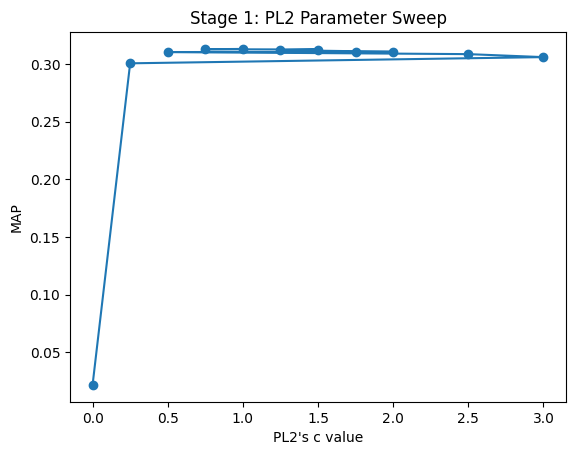

In [ ]:
plt.plot(stage1_df["c"],stage1_df["MAP"],marker="o")
plt.xlabel("PL2's c value")
plt.ylabel("MAP")
plt.title("Stage 1: PL2 Parameter Sweep")
plt.show()

In [ ]:
best_c = stage1_df.iloc[0]["c"]
best_map = stage1_df.iloc[0]["MAP"]

print("Best c:",best_c)
print("Best MAP:",best_map)

Best c: 1.0
Best MAP: 0.31317394590278563


In [ ]:
# stage1_df = pd.DataFrame({
#     "c": rtr1["tran_0_c"],
#     "MAP": rtr1["map"]
# }).sort_values("MAP",ascending=False)

# stage1_df

In [ ]:
#stage 2

stage2_values = [
    0.80,0.85,0.90,0.95,1.00,
    1.05,1.10,1.15,1.20
]

results = []

for c in stage2_values:

    pl2 = pt.terrier.Retriever(
        index,
        wmodel="PL2",
        controls={"c": str(c)}
    )

    start = time.perf_counter()
    results_pl2 = pl2.transform(query)
    search_time = time.perf_counter() - start

    evaluation = pt.Evaluate(
        results_pl2,
        qrels,
        metrics=["map"]
    )

    results.append({
        "c": c,
        "MAP": evaluation["map"],
        "Search Time (s)": search_time
    })

stage2_df = pd.DataFrame(results).sort_values(
    by="MAP",
    ascending=False
)

stage2_df

,c,MAP,Search Time (s)
1,0.85,0.314780,6.195221
2,0.90,0.314516,4.256675
0,0.80,0.313785,4.927875
5,1.05,0.313694,7.836527
3,0.95,0.313489,5.099908
6,1.10,0.313422,4.472161
4,1.00,0.313174,5.814440
8,1.20,0.313133,6.230935
7,1.15,0.313062,4.536110


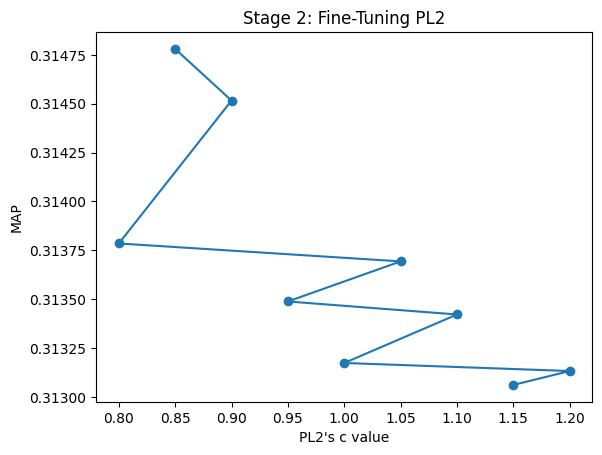

In [ ]:
plt.plot(stage2_df["c"],stage2_df["MAP"],marker="o")
plt.xlabel("PL2's c value")
plt.ylabel("MAP")
plt.title("Stage 2: Fine-Tuning PL2")
plt.show()

In [ ]:
best_c = stage2_df.iloc[0]["c"]
best_map = stage2_df.iloc[0]["MAP"]

print("Final Best c:",best_c)
print("Final Best MAP:",best_map)

Final Best c: 0.85
Final Best MAP: 0.3147803688036112


In [ ]:
#stage 3

stage3_values = [
    0.80,0.81,0.82,0.83,0.84,
    0.85,
    0.86,0.87,0.88,0.89,0.90
]

results = []

for c in stage3_values:

    pl2 = pt.terrier.Retriever(
        index,
        wmodel="PL2",
        controls={"c": str(c)}
    )

    start = time.perf_counter()
    results_pl2 = pl2.transform(query)
    search_time = time.perf_counter() - start

    evaluation = pt.Evaluate(
        results_pl2,
        qrels,
        metrics=["map"]
    )

    results.append({
        "c": c,
        "MAP": evaluation["map"],
        "Search Time (s)": search_time
    })

stage3_df = pd.DataFrame(results).sort_values(
    by="MAP",
    ascending=False
)

stage3_df

,c,MAP,Search Time (s)
1,0.81,0.314782,4.744558
5,0.85,0.314780,4.625364
4,0.84,0.314740,5.078709
2,0.82,0.314559,5.729717
3,0.83,0.314546,4.935102
7,0.87,0.314530,5.671442
10,0.90,0.314516,4.289133
9,0.89,0.314449,5.428001
6,0.86,0.314407,4.389294
8,0.88,0.314240,4.294746


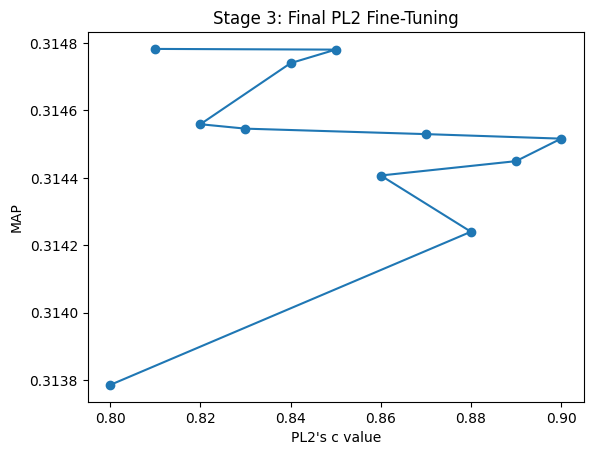

In [ ]:
plt.plot(stage3_df["c"],stage3_df["MAP"],marker="o")
plt.xlabel("PL2's c value")
plt.ylabel("MAP")
plt.title("Stage 3: Final PL2 Fine-Tuning")
plt.show()

In [ ]:
best_c = stage3_df.iloc[0]["c"]
best_map = stage3_df.iloc[0]["MAP"]

print("Final Best c:",best_c)
print("Final Best MAP:",best_map)

Final Best c: 0.81
Final Best MAP: 0.314782445460448


In [ ]:
best_c = 0.81

pl2 = pt.terrier.Retriever(
    index,
    wmodel="PL2",
    controls={"c": str(best_c)}
)

start = time.perf_counter()
pl2_results = pl2.transform(query)
search_time = time.perf_counter() - start

pl2_eval = pt.Evaluate(
    pl2_results,
    qrels,
    metrics=[
        "map",
        "recip_rank",
        "P.5",
        "P.10",
        "ndcg_cut.10"
    ]
)

print("Final PL2 Results")
print("c =",best_c)
print("MAP =",pl2_eval["map"])
print("MRR =",pl2_eval["recip_rank"])
print("P@5 =",pl2_eval["P.5"])
print("P@10 =",pl2_eval["P.10"])
print("nDCG@10 =",pl2_eval["ndcg_cut.10"])
print("Search Time =",search_time)

Final PL2 Results
c = 0.81
MAP = 0.314782445460448
MRR = 0.5523094696093459
P@5 = 0.3235555555555557
P@10 = 0.23466666666666688
nDCG@10 = 0.34190400231197904
Search Time = 5.10165725700017


In [ ]:
# stage2_df = pd.DataFrame({
#     "c": rtr2["tran_0_c"],
#     "MAP": rtr2["map"]
# }).sort_values("MAP",ascending=False)

# stage2_df

In [ ]:
# best = stage2_df.iloc[0]

# print("Best c:",best["c"])
# print("Best MAP:",best["MAP"])
# print("Best MRR:",best["MRR"])
# print("Best P@5:",best["P@5"])
# print("Best P@10:",best["P@10"])
# print("Best nDCG@10:",best["nDCG@10"])

In [ ]:
#best = results_df.iloc[0]

In [ ]:
#best

In [ ]:
##Final Results

best_c = 0.81

pl2 = pt.terrier.Retriever(
    index,
    wmodel="PL2",
    controls={"c":str(best_c)}
)

start = time.perf_counter()
pl2_results = pl2.transform(query)
search_time = time.perf_counter() - start

pl2_eval = pt.Evaluate(
    pl2_results,
    qrels,
    metrics=[
        "map",
        "recip_rank",
        "P.5",
        "P.10",
        "ndcg_cut.10"
    ]
)

print("Final PL2 Results")
print("Best c:",best_c)
print("MAP:",pl2_eval["map"])
print("MRR:",pl2_eval["recip_rank"])
print("P@5:",pl2_eval["P.5"])
print("P@10:",pl2_eval["P.10"])
print("nDCG@10:",pl2_eval["ndcg_cut.10"])
print("Search Time:",search_time)

Final PL2 Results
Best c: 0.81
MAP: 0.314782445460448
MRR: 0.5523094696093459
P@5: 0.3235555555555557
P@10: 0.23466666666666688
nDCG@10: 0.34190400231197904
Search Time: 5.4453450000000885


In [ ]:
# pl2 = pt.terrier.Retriever(
#     index,
#     wmodel="PL2",
#     controls={'c': 1}
# )

# rtr = pt.GridScan(
#     pl2,
#     {pl2: {'c': [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]}},
#     query,
#     qrels,
#     ["map"]
# )

# import matplotlib.pyplot as plt

# plt.plot(rtr["tran_0_c"], rtr["map"])

# plt.xlabel("PL2's c value")
# plt.ylabel("MAP")

# plt.show()

In [ ]:
# #new
# pl2 = pt.terrier.Retriever(
#     index,
#     wmodel="PL2"
# )

# rtr = pt.GridScan(
#     pl2,
#     {pl2: {'c': [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]}},
#     query,
#     qrels,
#     ["map"]
# )

# import matplotlib.pyplot as plt

# plt.plot(rtr["tran_0_c"], rtr["map"])

# plt.xlabel("PL2's c value")
# plt.ylabel("MAP")

# plt.show()
